In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "oasis_longitudinal.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jboysen/mri-and-alzheimers",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/Users/ihsanbolum/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_55081/238782329.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:   Subject ID         MRI ID        Group  Visit  MR Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  


In [2]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

df = df.copy()


df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [3]:
df["Visit"].describe()

count    373.000000
mean       1.882038
std        0.922843
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        5.000000
Name: Visit, dtype: float64

In [4]:
features_pca = ["MR Delay", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]

df["SES"] = df["SES"].fillna(df["SES"].median())
df["MMSE"] = df["MMSE"].fillna(df["MMSE"].median())

df_visit_1 = df[df["Visit"] == 1].copy()


scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_visit_1[features_pca])

scaled_data.shape

(150, 8)

# PCA 
### Visit 1 

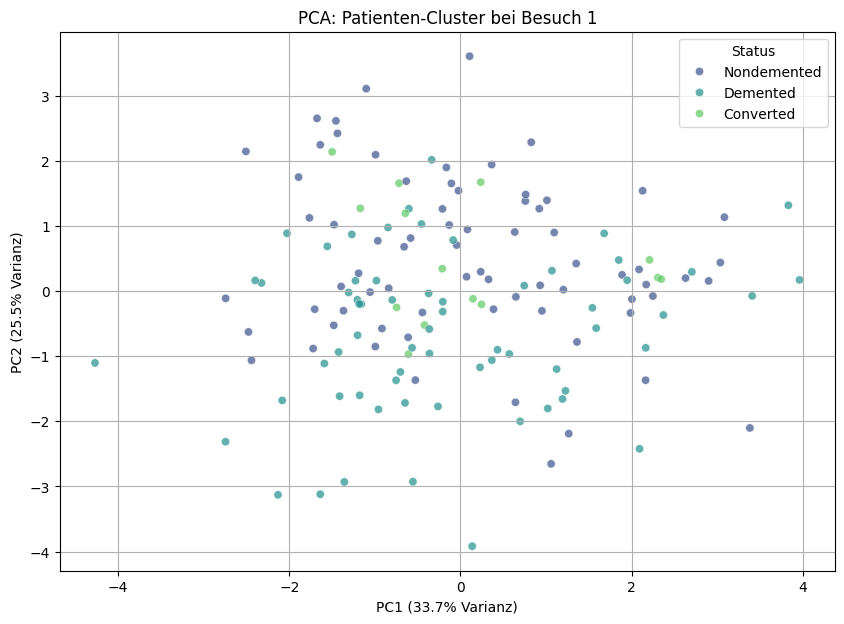

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca =PCA(n_components=2)
pca_res = pca.fit_transform(scaled_data)


df_pca = pd.DataFrame(data = pca_res, columns= ["PC1", "PC2"], index=df_visit_1.index)
df_pca["Status"] = df_visit_1["Group"].values

# visualise

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Status', data=df_pca, palette='viridis', alpha=0.7)
plt.title('PCA: Patienten-Cluster bei Besuch 1')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)')
plt.grid(True)
plt.show()

# PCA 
### Visit 2

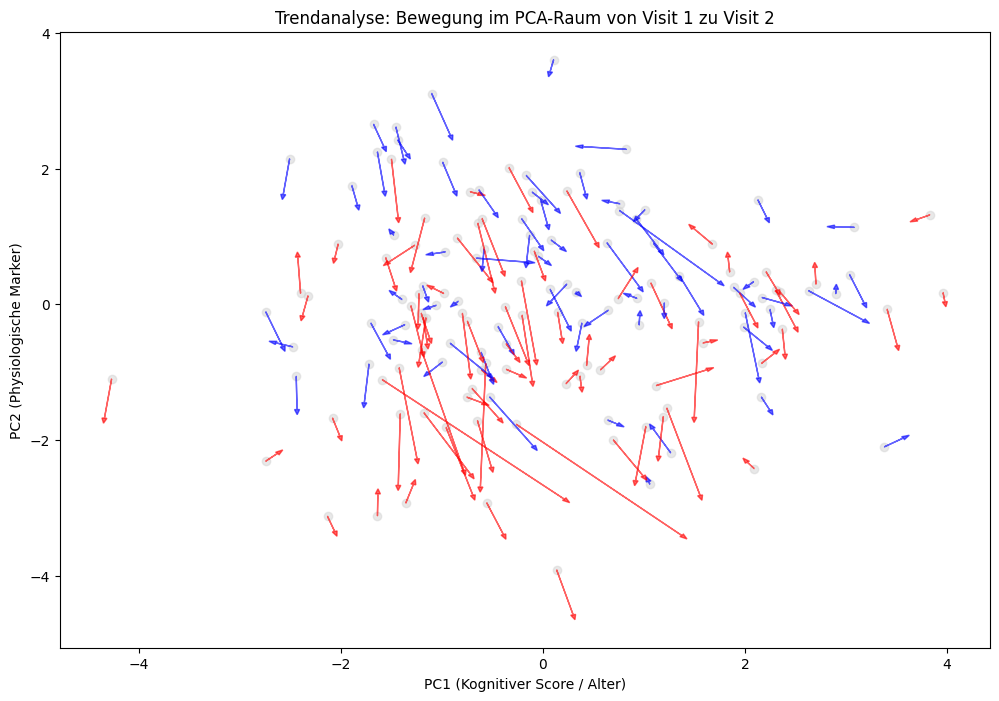

In [6]:
df_visit_2 = df[df["Visit"] == 2].copy()
common_ids = set(df_visit_1["Subject ID"]).intersection(set(df_visit_2["Subject ID"]))
v1_sub = df_visit_1[df_visit_1["Subject ID"].isin(common_ids)].sort_values("Subject ID")
v2_sub = df_visit_2[df_visit_2["Subject ID"].isin(common_ids)].sort_values("Subject ID")

scaled_v1 = scaler.transform(v1_sub[features_pca])
scaled_v2 = scaler.transform(v2_sub[features_pca])

pca_v1 = pca.transform(scaled_v1)
pca_v2 = pca.transform(scaled_v2)

plt.figure(figsize=(12, 8))
plt.scatter(pca_v1[:, 0], pca_v1[:, 1], c='lightgrey', alpha=0.5, label='Start (Visit 1)')

for i in range(len(pca_v1)):
    color = 'blue' if v2_sub.iloc[i]['Group'] == 'Nondemented' else 'red'
    plt.arrow(pca_v1[i, 0], pca_v1[i, 1], 
            pca_v2[i, 0] - pca_v1[i, 0], 
            pca_v2[i, 1] - pca_v1[i, 1], 
            head_width=0.05, color=color, alpha=0.6)
    

plt.title('Trendanalyse: Bewegung im PCA-Raum von Visit 1 zu Visit 2')
plt.xlabel('PC1 (Kognitiver Score / Alter)')
plt.ylabel('PC2 (Physiologische Marker)')
plt.show()


#### "Converted"-Vorhersage (Das Frühwarnsystem)

In [7]:
import pandas as pd 
import numpy as np 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz



df_visit_1
y = df_visit_1["Group"]
df_visit_1_rf = df_visit_1.copy()
mapping_sex = {"M": 0, "F": 1}
mapping_hand = {"R": 0, "L": 1}
df_visit_1_rf["M/F"] =df_visit_1_rf["M/F"].map(mapping_sex)
df_visit_1_rf["Hand"] = df_visit_1_rf["Hand"].map(mapping_hand)

X = df_visit_1_rf[df_visit_1.columns[4:]]
X = X.drop(columns="CDR")



In [8]:
X

,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,eTIV,nWBV,ASF
0,0,0,0,87,14,2.0,27.0,1987,0.696,0.883
2,0,0,0,75,12,2.0,23.0,1678,0.736,1.046
5,0,1,0,88,18,3.0,28.0,1215,0.710,1.444
7,0,0,0,80,12,4.0,28.0,1689,0.712,1.039
10,0,0,0,71,16,2.0,28.0,1357,0.748,1.293
...,...,...,...,...,...,...,...,...,...,...
359,0,0,0,73,12,2.0,23.0,1661,0.698,1.056
361,0,1,0,66,13,2.0,30.0,1495,0.746,1.174
365,0,1,0,72,16,3.0,24.0,1354,0.733,1.296
367,0,0,0,80,16,1.0,28.0,1704,0.711,1.030


In [9]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_predictions = rf.predict(x_test)

acc = accuracy_score(y_test, y_predictions)

acc

0.7

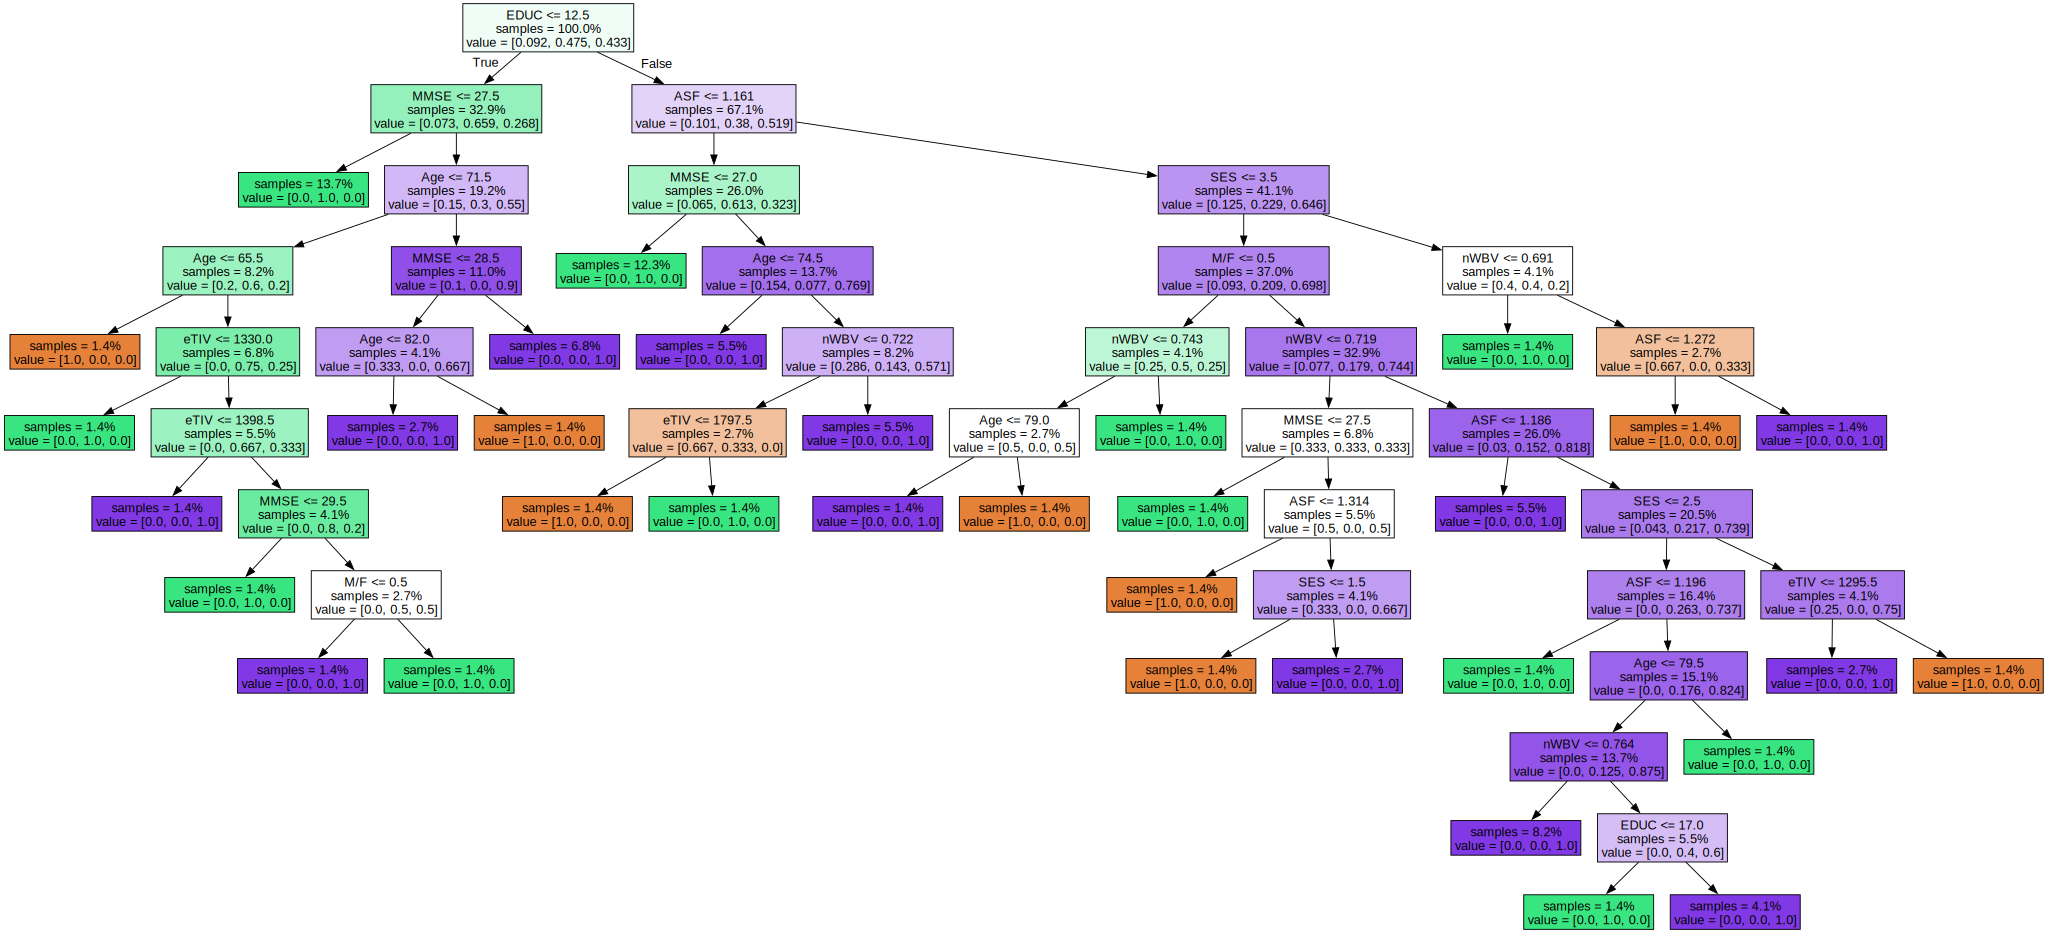

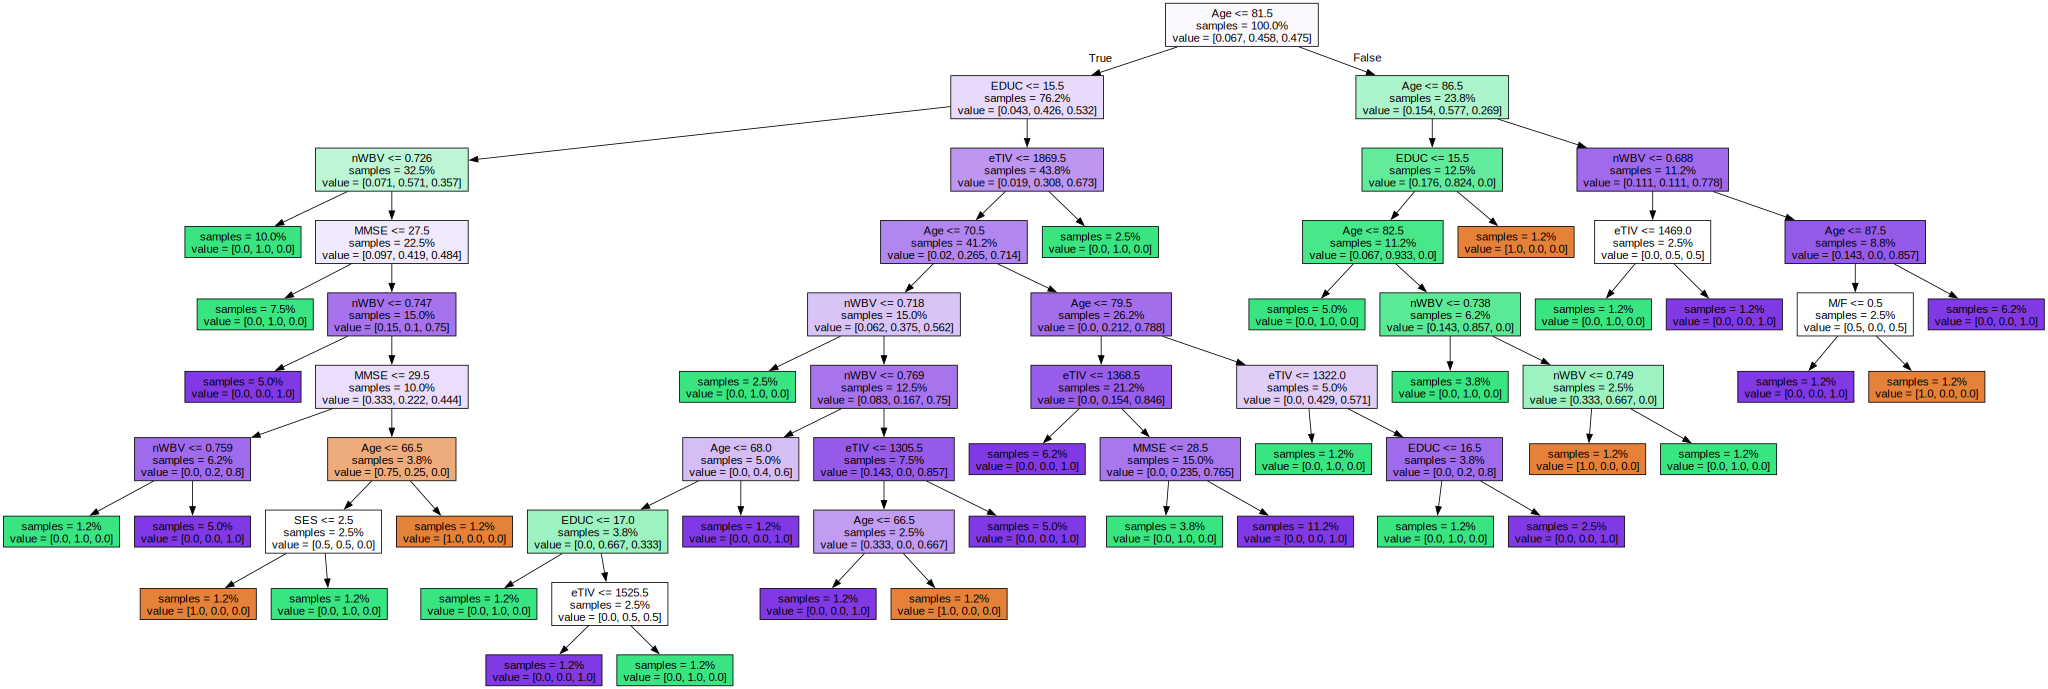

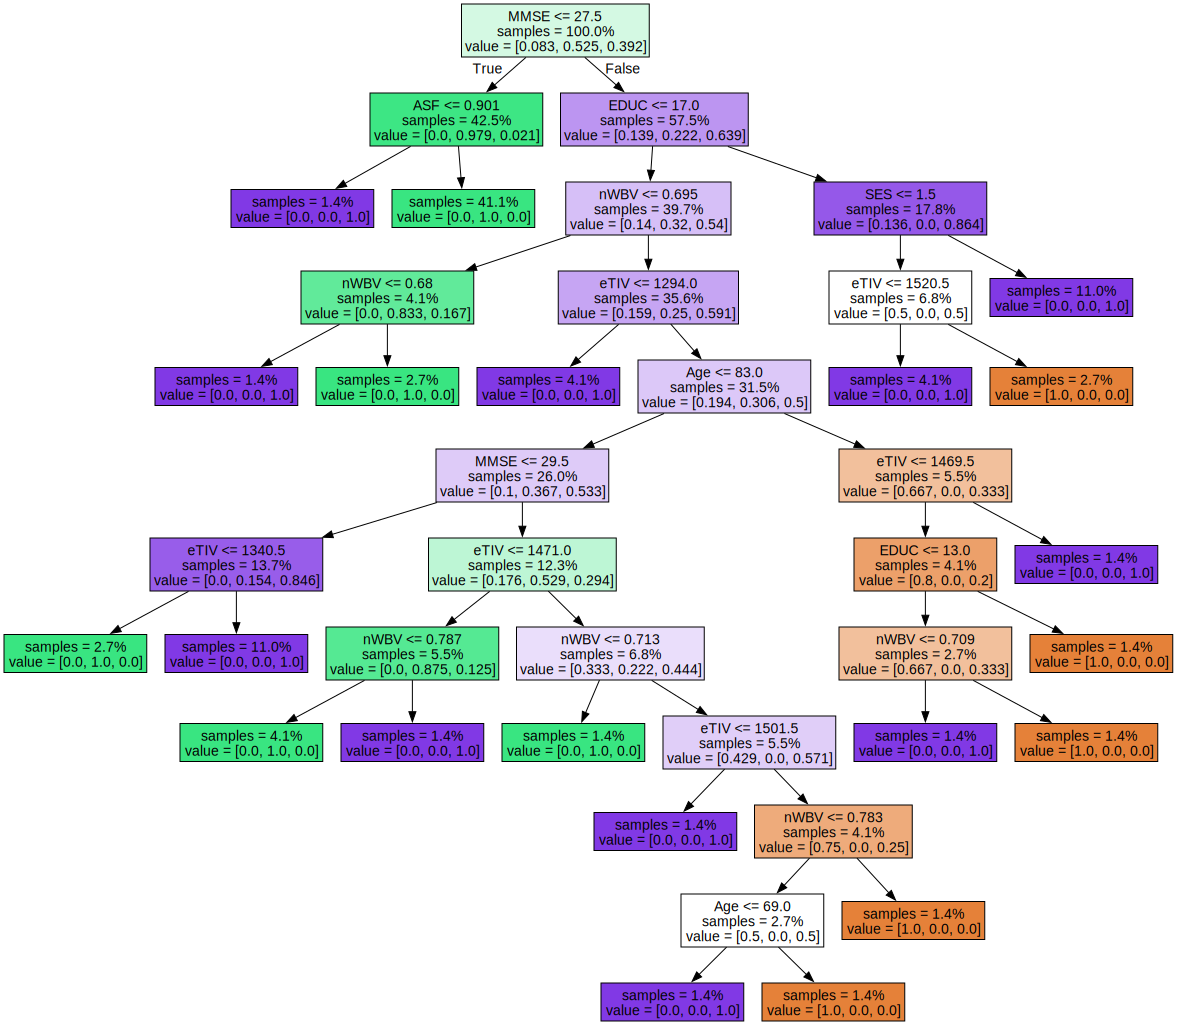

In [10]:
for i in range(3):
    tree = rf.estimators_[i]
    data = export_graphviz(
        tree, 
        feature_names=X_train.columns,
        filled=True,
        max_depth=None,
        impurity=False,
        proportion=True
    )
    graph = graphviz.Source(data)
    display(graph)

# DementiaPredictor (OOP)

In [11]:
class DementiaPreictor:
    def __init__(self,X,y):
        self.X = X
        self.y = y

        self.model = RandomForestClassifier(random_state=42)
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.accuracy = None
        
    def train(self):
        print("Splitting data and traning the model")
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
        self.X, self.y, test_size = 0.2, random_state = 42, stratify= self.y
        )

        self.model.fit(self.X_train, self.y_train)
        print("Traning done")

    def evaluate(self):
        print("Evaluation")
        predictions = self.model.predict(self.X_test)

        self.accuracy = accuracy_score(self.y_test, predictions)
        print(f"Model Accu.: {self.accuracy * 100:.2f}%")


predictor = DementiaPreictor(X,y)


In [12]:
predictor.train()

predictor.evaluate()

Splitting data and traning the model
Traning done
Evaluation
Model Accu.: 70.00%


oop w child class

In [13]:
from sklearn.linear_model import LogisticRegression


class BaseMedicalPredictor:
    def __init__(self, X,y):
        self.X = X
        self.y = y
        self.scaler = StandardScaler()
        self.model = None

        self.X_train_scaled = None
        self.X_test_scaled = None
        self.y_train = None
        self.y_test = None

    def prepare_data(self):
        X_train, X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42, stratify=self.y)


        self.X_train_scaled = self.scaler.fit_transform(X_train)
        self.X_test_scaled = self.scaler.fit_transform(X_test)

    def evaluate(self):

        if self.model is None:
            print("Kein Model")
            return
        predictions = self.model.predict(self.X_test_scaled)
        accu = accuracy_score(self.y_test, predictions)
        print(f"model acc.: {accu*100}")

    def train(self):
        pass

class DementiaRandomForest(BaseMedicalPredictor):
    def __init__(self,X,y, trees=100):
        super().__init__(X,y)
        self.model = RandomForestClassifier(n_estimators=trees, random_state=42)
    def train(self):
        print("Train RF")
        self.prepare_data()
        self.model.fit(self.X_train_scaled, self.y_train)


class demetiaLogReg(BaseMedicalPredictor):
    def __init__(self, X,y,c_value=1.0):
        super().__init__(X,y)

        self.model = LogisticRegression(C=c_value, random_state=42)

    def train(self):
        print("Train Logistische Reg")
        self.prepare_data()
        self.model.fit(self.X_train_scaled, self.y_train)

In [14]:
rf_modell = DementiaRandomForest(X, y, trees=100)
rf_modell.train()
rf_modell.evaluate()


log_modell = demetiaLogReg(X, y, c_value=0.5)
log_modell.train()
log_modell.evaluate()

Train RF
model acc.: 66.66666666666666
Train Logistische Reg
model acc.: 73.33333333333333


# PCA Trajectory Predictor

In [15]:
df

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,2.0,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,Nondemented,2,763,F,R,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [16]:
patience = df.copy() 
len(patience["Visit"] == 1)

373

In [17]:
len(patience[patience["Visit"] == 4])

15

In [18]:
map_dem = {
    "Nondemented": 0,
    "Demented": 1,
    "Converted": 1
}

map_sex = {
    "M": 1,
    "F": 0
}

map_hand = {
    "R": 0,
    "L":1
}

patience["Group"] = patience["Group"].map(map_dem)
patience["Hand"] = patience["Hand"].map(map_hand)
patience["M/F"] = patience["M/F"].map(map_sex)

patience

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,1,3,1895,1,0,80,12,2.0,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,1,2,842,1,0,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,1,3,2297,1,0,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,0,2,763,0,0,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [19]:

ids_1 = patience[patience["Visit"] == 1]["Subject ID"]
ids_2 = patience[patience["Visit"] == 2]["Subject ID"]
ids_3 = patience[patience["Visit"] == 3]["Subject ID"]


ids_pool_1_2 = set(ids_1).intersection(set(ids_2)).intersection(set(ids_3))


patience_1_2 = patience[patience["Subject ID"].isin(ids_pool_1_2)]




In [20]:
patience_1_2 = patience_1_2[patience_1_2["Visit"].isin([1,2,3])]

In [21]:
patience_1_2

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,1,3,1895,1,0,80,12,2.0,22.0,0.5,1698,0.701,1.034
7,OAS2_0005,OAS2_0005_MR1,0,1,0,1,0,80,12,4.0,28.0,0.0,1689,0.712,1.039
8,OAS2_0005,OAS2_0005_MR2,0,2,1010,1,0,83,12,4.0,29.0,0.5,1701,0.711,1.032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,1,2,842,1,0,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,1,3,2297,1,0,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,0,2,763,0,0,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [22]:
unique_ids = patience_1_2["Subject ID"].unique()

In [23]:
unique_ids

array(['OAS2_0002', 'OAS2_0005', 'OAS2_0012', 'OAS2_0013', 'OAS2_0020',
       'OAS2_0027', 'OAS2_0031', 'OAS2_0034', 'OAS2_0037', 'OAS2_0040',
       'OAS2_0041', 'OAS2_0044', 'OAS2_0048', 'OAS2_0049', 'OAS2_0051',
       'OAS2_0057', 'OAS2_0058', 'OAS2_0061', 'OAS2_0062', 'OAS2_0064',
       'OAS2_0067', 'OAS2_0070', 'OAS2_0073', 'OAS2_0076', 'OAS2_0078',
       'OAS2_0079', 'OAS2_0080', 'OAS2_0090', 'OAS2_0095', 'OAS2_0100',
       'OAS2_0101', 'OAS2_0102', 'OAS2_0103', 'OAS2_0117', 'OAS2_0119',
       'OAS2_0126', 'OAS2_0127', 'OAS2_0129', 'OAS2_0140', 'OAS2_0143',
       'OAS2_0147', 'OAS2_0152', 'OAS2_0161', 'OAS2_0171', 'OAS2_0174',
       'OAS2_0175', 'OAS2_0176', 'OAS2_0178', 'OAS2_0181', 'OAS2_0183',
       'OAS2_0185', 'OAS2_0186'], dtype=object)

In [24]:
df_train_id, df_test_id = train_test_split(unique_ids, test_size=0.2, random_state=42)

df_train = patience_1_2[patience_1_2["Subject ID"].isin(df_train_id)]
df_test = patience_1_2[patience_1_2["Subject ID"].isin(df_test_id)]

In [25]:
df_train

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,1,3,1895,1,0,80,12,2.0,22.0,0.5,1698,0.701,1.034
7,OAS2_0005,OAS2_0005_MR1,0,1,0,1,0,80,12,4.0,28.0,0.0,1689,0.712,1.039
8,OAS2_0005,OAS2_0005_MR2,0,2,1010,1,0,83,12,4.0,29.0,0.5,1701,0.711,1.032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,OAS2_0183,OAS2_0183_MR2,0,2,182,0,0,66,13,2.0,30.0,0.0,1506,0.740,1.165
363,OAS2_0183,OAS2_0183_MR3,0,3,732,0,0,68,13,2.0,30.0,0.0,1506,0.740,1.165
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,0,2,763,0,0,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [26]:
df_test

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
22,OAS2_0013,OAS2_0013_MR1,0,1,0,0,0,81,12,4.0,30.0,0.0,1230,0.715,1.427
23,OAS2_0013,OAS2_0013_MR2,0,2,643,0,0,82,12,4.0,30.0,0.0,1212,0.720,1.448
24,OAS2_0013,OAS2_0013_MR3,0,3,1456,0,0,85,12,4.0,29.0,0.0,1225,0.710,1.433
47,OAS2_0027,OAS2_0027_MR1,0,1,0,0,0,69,12,3.0,29.0,0.0,1365,0.783,1.286
48,OAS2_0027,OAS2_0027_MR2,0,2,609,0,0,71,12,3.0,30.0,0.0,1360,0.782,1.291
49,OAS2_0027,OAS2_0027_MR3,0,3,1234,0,0,73,12,3.0,30.0,0.0,1358,0.775,1.293
97,OAS2_0048,OAS2_0048_MR1,1,1,0,1,0,66,16,1.0,19.0,1.0,1695,0.711,1.036
98,OAS2_0048,OAS2_0048_MR2,1,2,248,1,0,66,16,1.0,21.0,1.0,1708,0.703,1.028
99,OAS2_0048,OAS2_0048_MR3,1,3,647,1,0,68,16,1.0,19.0,1.0,1712,0.691,1.025
102,OAS2_0049,OAS2_0049_MR1,0,1,0,0,0,69,16,3.0,30.0,0.0,1491,0.794,1.177


In [27]:
scale = StandardScaler()
pca = PCA(n_components=2)
def scale_data_PCA(df, n):

    pca_featres = ["MR Delay"	,"M/F"	,"Hand"	,"Age"	,"EDUC"	,"SES"	,"MMSE"	,"CDR"	,"eTIV"	,"nWBV","ASF"]

    if n == 1: #train
        

        pca_scale = scale.fit_transform(df[pca_featres])
        pca_res = pca.fit_transform(pca_scale)

        pca_res = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"], index=df.index)
        df = pd.concat([df, pca_res], axis=1)
        return df

    if n == 2 : #test

        pca_scale = scale.fit_transform(df[pca_featres])
        pca_res = pca.transform(pca_scale)

        pca_res = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"], index=df.index)



        df = pd.concat([df, pca_res], axis=1)
        return df
    return

In [28]:
df_train = scale_data_PCA(df_train,1)
df_test = scale_data_PCA(df_test,2)

In [29]:
features_lstm = ["MR Delay",	"Age"	,"EDUC"	,"SES"	,"MMSE"	,"CDR"	,"eTIV"	,"nWBV"	,"ASF"]

df_train[features_lstm] = scaler.fit_transform(df_train[features_lstm])
df_test[features_lstm] = scaler.transform(df_test[features_lstm])

df_test

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,PC1,PC2
22,OAS2_0013,OAS2_0013_MR1,0,1,-1.121145,0,0,0.415306,-0.960469,1.545455,0.634519,-0.657967,-1.741937,-0.325473,2.022982,1.682612,-1.050640
23,OAS2_0013,OAS2_0013_MR2,0,2,-0.067404,0,0,0.546624,-0.960469,1.545455,0.634519,-0.657967,-1.853841,-0.179153,2.191738,1.732438,-1.022956
24,OAS2_0013,OAS2_0013_MR3,0,3,1.264932,0,0,0.940578,-0.960469,1.545455,0.268107,-0.657967,-1.773022,-0.471793,2.071198,1.547186,-0.524285
47,OAS2_0027,OAS2_0027_MR1,0,1,-1.121145,0,0,-1.160509,-0.960469,0.613636,0.268107,-0.657967,-0.902660,1.664481,0.889905,1.431201,-1.758206
48,OAS2_0027,OAS2_0027_MR2,0,2,-0.123122,0,0,-0.897873,-0.960469,0.613636,0.634519,-0.657967,-0.933744,1.635217,0.930085,1.267279,-1.722448
49,OAS2_0027,OAS2_0027_MR3,0,3,0.901121,0,0,-0.635237,-0.960469,0.613636,0.634519,-0.657967,-0.946178,1.430369,0.946157,1.140993,-1.483122
97,OAS2_0048,OAS2_0048_MR1,1,1,-1.121145,1,0,-1.554463,0.320156,-1.250000,-3.396017,2.714112,1.148908,-0.442529,-1.119095,0.041919,2.927692
98,OAS2_0048,OAS2_0048_MR2,1,2,-0.714725,1,0,-1.554463,0.320156,-1.250000,-2.663192,2.714112,1.229728,-0.676642,-1.183383,-0.229771,2.860217
99,OAS2_0048,OAS2_0048_MR3,1,3,-0.060848,1,0,-1.291827,0.320156,-1.250000,-3.396017,2.714112,1.254595,-1.027810,-1.207491,-0.227426,3.371952
102,OAS2_0049,OAS2_0049_MR1,0,1,-1.121145,0,0,-1.160509,0.320156,0.613636,0.634519,-0.657967,-0.119334,1.986386,0.013981,0.206689,-1.761984


In [30]:
def reshape_dim(df, features, n_visit):
    n_id = df["Subject ID"].nunique()
    n_features = len(features)
    print(n_id)

    df = df.sort_values(by=["Subject ID", "Visit"] )

    df_3d = df[features].values.reshape(n_id, n_visit, n_features)

    

    return df_3d

In [31]:
df_test_3d = reshape_dim(df_test, features_lstm, 3)
df_train_3d = reshape_dim(df_train, features_lstm, 3)

print(df_test_3d.shape, df_train_3d.shape)

11
41
(11, 3, 9) (41, 3, 9)


In [80]:
X_train_2v = df_train_3d[:, :2, :]
X_test_2v = df_test_3d[:, :2, :]

X_test_2v.shape, X_train_2v.shape

X_train_2v = np.asarray(X_train_2v).astype('float32')
X_test_2v = np.asarray(X_test_2v).astype('float32')

In [81]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout


inputs = Input(shape=(2, 9), name='input_layer')
lstm_out= LSTM(units=2, activation="tanh")(inputs)

dropout_ra = Dropout(0.5)(lstm_out)

pca_output = Dense(units=2, activation="linear", name="pca_prediction")(dropout_ra)
group_output = Dense(units=1, activation="sigmoid", name="group_prediction")(dropout_ra)

model = Model(inputs=inputs, outputs=[pca_output, group_output])

model.compile(
    optimizer="adam",
    loss={
        "pca_prediction": "mse",
        "group_prediction": "binary_crossentropy"
    },
    metrics={
        'pca_prediction': 'mae',                 
        'group_prediction': 'accuracy'
    },
    loss_weights={
       'pca_prediction': 1.0, 
        'group_prediction': 0.8 
    }
)




In [82]:
df_train

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,PC1,PC2
2,OAS2_0002,OAS2_0002_MR1,1,1,-1.121145,1,0,-0.372601,-0.960469,-0.318182,-1.930368,1.028073,1.043221,0.289072,-1.038735,0.310089,1.960884
3,OAS2_0002,OAS2_0002_MR2,1,2,-0.203423,1,0,-0.241283,-0.960469,-0.318182,-0.098306,1.028073,1.416234,-0.384001,-1.328031,-0.705989,1.765860
4,OAS2_0002,OAS2_0002_MR3,1,3,1.984360,1,0,0.283988,-0.960469,-0.318182,-2.296780,1.028073,1.167559,-0.735170,-1.135167,-0.144858,3.105609
7,OAS2_0005,OAS2_0005_MR1,0,1,-1.121145,1,0,0.283988,-0.960469,1.545455,-0.098306,-0.657967,1.111607,-0.413265,-1.094987,-0.369921,1.207082
8,OAS2_0005,OAS2_0005_MR2,0,2,0.534032,1,0,0.677942,-0.960469,1.545455,0.268107,1.028073,1.186210,-0.442529,-1.151239,-0.180686,2.171639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,OAS2_0183,OAS2_0183_MR2,0,2,-0.822885,0,0,-1.554463,-0.640312,-0.318182,0.634519,-0.657967,-0.026081,0.406128,-0.082451,0.289030,-1.550687
363,OAS2_0183,OAS2_0183_MR3,0,3,0.078449,0,0,-1.291827,-0.640312,-0.318182,0.634519,-0.657967,-0.026081,0.406128,-0.082451,0.186703,-1.393570
370,OAS2_0186,OAS2_0186_MR1,0,1,-1.121145,0,0,-2.211053,-0.640312,-0.318182,0.634519,-0.657967,-1.188636,2.191234,1.251526,1.869806,-3.068467
371,OAS2_0186,OAS2_0186_MR2,0,2,0.129251,0,0,-1.948417,-0.640312,-0.318182,0.634519,-0.657967,-1.138901,2.044914,1.187237,1.675734,-2.776351


In [87]:

y_train_pca = df_train.groupby("Subject ID")[["PC1", "PC2"]].first()
y_train_group = df_train.groupby("Subject ID")["Visit"].first()

y_test_pca = df_test.groupby("Subject ID")[["PC1", "PC2"]].first()
y_test_group = df_test.groupby("Subject ID")["Visit"].first()

y_train_dict = {
    'pca_prediction': y_train_pca,
    'group_prediction': y_train_group
}

y_test_dict = {
    'pca_prediction': y_test_pca,
    'group_prediction': y_test_group
}


y_train_dict['pca_prediction'] = np.asarray(y_train_dict['pca_prediction']).astype('float32')
y_train_dict['group_prediction'] = np.asarray(y_train_dict['group_prediction']).astype('float32')

y_test_dict['pca_prediction'] = np.asarray(y_test_dict['pca_prediction']).astype('float32')
y_test_dict['group_prediction'] = np.asarray(y_test_dict['group_prediction']).astype('float32')
history = model.fit(
    X_train_2v,           
    y_train_dict,         
    epochs=60,
    batch_size=8,
    validation_data=(X_test_2v, y_test_dict),
    verbose=1,

)

Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - group_prediction_accuracy: 0.9047 - group_prediction_loss: 0.4728 - loss: 2.3039 - pca_prediction_loss: 1.9147 - pca_prediction_mae: 1.1150 - val_group_prediction_accuracy: 1.0000 - val_group_prediction_loss: 0.4264 - val_loss: 2.2294 - val_pca_prediction_loss: 1.7289 - val_pca_prediction_mae: 1.1090
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - group_prediction_accuracy: 0.9163 - group_prediction_loss: 0.4809 - loss: 2.3621 - pca_prediction_loss: 1.9068 - pca_prediction_mae: 1.1496 - val_group_prediction_accuracy: 1.0000 - val_group_prediction_loss: 0.4239 - val_loss: 2.2225 - val_pca_prediction_loss: 1.7240 - val_pca_prediction_mae: 1.1070
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - group_prediction_accuracy: 0.9640 - group_prediction_loss: 0.4171 - loss: 2.1169 - pca_prediction_loss: 1.7479 - pca_prediction_mae: 1.0638 - val_group_prediction_accuracy: 1.0000 - val_group_prediction_loss: 0.4213 - val_loss: 2.2149 - val_pca_p

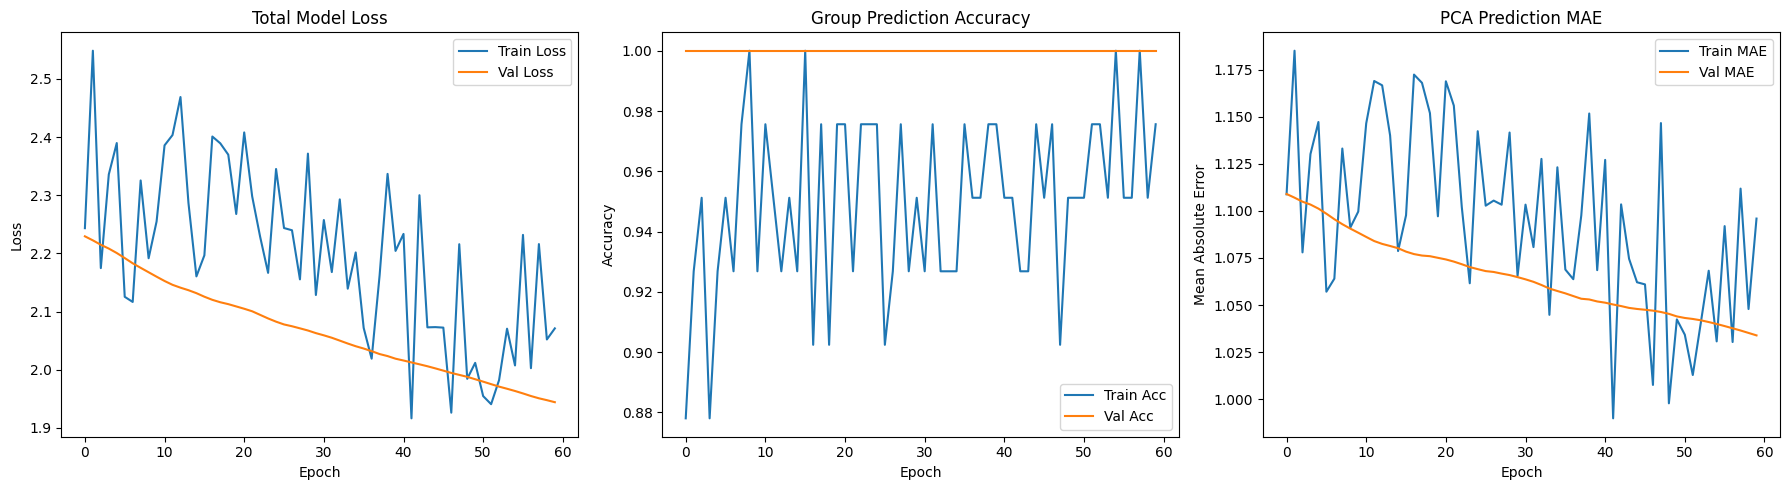

In [88]:
import matplotlib.pyplot as plt

def plot_history(history):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))


    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Total Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['group_prediction_accuracy'], label='Train Acc')
    ax2.plot(history.history['val_group_prediction_accuracy'], label='Val Acc')
    ax2.set_title('Group Prediction Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()


    ax3.plot(history.history['pca_prediction_mae'], label='Train MAE')
    ax3.plot(history.history['val_pca_prediction_mae'], label='Val MAE')
    ax3.set_title('PCA Prediction MAE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Mean Absolute Error')
    ax3.legend()

    plt.tight_layout()
    plt.show()


plot_history(history)

In [91]:
model.save('pca_trajectory_model.keras')